In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Micrograd Lesson 01

Notes and experiments while following Andrej Karpathy's micrograd course.

1. Backpropagation: minimize the loss function and improve the accuracy of the network
2. micrograd: number of operations
3. Backpropagation recursively applies the chain rule through a computation graph.
4. Micrograd is for better understanding propagations, but when training a production network, we need to use n tensors

# expresstion of backward()
g.backward() # use the chain rule of calculus, backward through the expression graph from node g
print(f'{a.grad:.4f}') # i.e. the numerical value of dg/da

In [4]:
def f(x):
    return 3*x**2 - 4*x +5

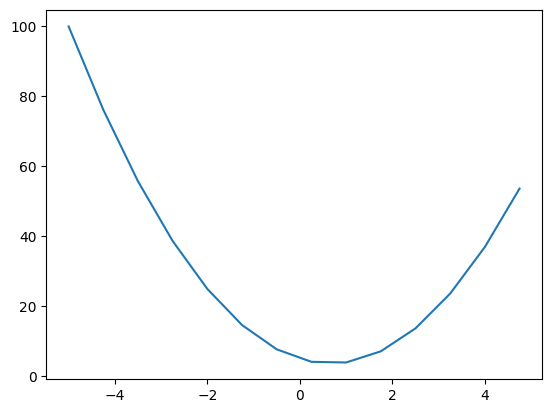

In [10]:
xs = np.arange(-5, 5, 0.75)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c

In [12]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [414]:
class Value:

     # self.attribute_name = the value passed in
     # _prev = previous values used to create this value

    
     def __init__(self, data, _children=(), _op='', label=''): 
         self.data = data
         self.grad = 0.0
         self._backward = lambda: None
         self._prev = set(_children)
         self._op = _op
         self.label = label
         
         
     #for nice expression
    
     def __repr__(self):
        return f"Value(data={self.data})"  


     def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        # if other already is a Value, then use the existing data, if not, then make other a Value(other) 包装成Value值

         
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            # 如果一个变量通过多条路径影响最终输出，那么每条路径的 gradient contribution 要累加, based on chain rule
        out._backward = _backward

        return out 


     def __mul__(self, other):
         other = other if isinstance(other, Value) else Value(other)
         out = Value(self.data * other.data, (self, other), '*')
         def _backward():
             self.grad += other.data * out.grad
             other.grad += self.data * out.grad
         out._backward = _backward
         
         return out
         
     def __pow__(self, other):

          assert isinstance(other, (int, float))
          out = Value(self.data**other, (self,), f'**{other}')

          def _backward():
                self.grad += other * self.data**(other - 1) * out.grad
          out._backward = _backward
          return out

     def  __truediv__(self, other):
         return self * other**-1
    
     def __rmul__(self, other): # other * self
         return self * other

     def __neg__(self, other):
         return self * -1

     def __sub__(self, other):
         return self + (-other)

     def __radd__(self, other):
         return self + other


     def tanh(self):
         x = self.data
         t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
         out = Value(t, (self, ), 'tanh')
         # (self, ) is a tuple

         def _backward():
            self.grad += (1 - t**2) * out.grad
             
         out._backward = _backward
         # if the function doesn't have an explicit return， Python implicitly returns None
    
         return out


     def exp(self):
         x = self.data
         out = Value(math.exp(x), (self,), 'exp')

         def _backward():
             self.grad += out.data * out.grad

         out._backward = _backward
         return out



     def backward(self):
            topo = []
            visited = set()
            def build_topo(v):
              if v not in visited:
                visited.add(v)
                for child in v._prev:
                  build_topo(child)
                topo.append(v)
            build_topo(self)
            
            self.grad = 1.0
            for node in reversed(topo):
              node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
# (a.__mul__(b)).__add__(c)




In [208]:
d._op

'+'

In [297]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

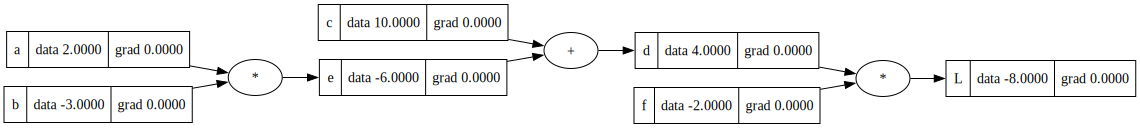

In [210]:
draw_dot(L)

In [211]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-8.0


In [429]:
L = d * f
dL / dc = (dL / dd) * (dd / dc) = -2.0
dL / de = (dL / dd) * (dd / de) = 4.0

dd / dc = 1.0
dd / de = 1.0
d = e + 


dL / de = -2.0

e = a * b
de / da = b 

dL / da = (dL / de) * (de / da)

SyntaxError: cannot assign to expression (2203259327.py, line 2)

In [ ]:
f.grad = 4.0
d.grad = -2
c.grad = -2
e.grad = -2
a.grad = (-2.0) * (-3.0)
b.grad = (-2.0) * 2.0

In [ ]:
def lol():
    h = 0.0001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L2 = L.data


    print((L2 - L1)/h)

lol()

In [ ]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();


In [ ]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
# tanh is an activation function like sigmoid, ReLU, etc.
o.backward()

In [ ]:
draw_dot(o)

In [ ]:
o.backward()

In [ ]:
 o.grad = 1.0

In [ ]:
# 0 = tanh(n)
# do/dn = 1 - o**2

In [ ]:
1 - o.data**2 

In [ ]:
n.grad =0.5

In [ ]:
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [ ]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

#chain rule

In [ ]:
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

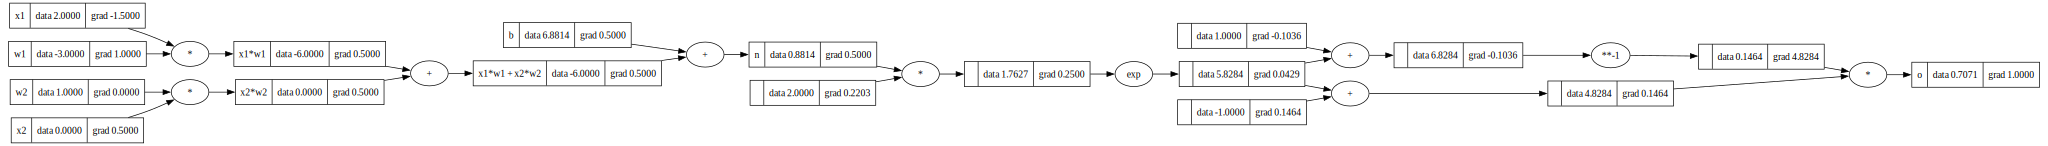

In [248]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ---
e = (2*n).exp()

o = (e - 1) / ( e + 1)


# ----
o.label = 'o'
# tanh is an activation function like sigmoid, ReLU, etc.

o.backward()

draw_dot(o)

Python syntax notes for micrograd


1. self.data = data
2. (self,) 单元素 tuple
3. _backward vs _backward()
4. other 是 Value 时用 other.data
5. other 是 int/float 时直接用 other
6. Jupyter 改 class 后要重新创建对象

In [254]:
import torch

x1 = torch.Tensor([2.0]).double();              x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();              x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();             w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();              w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [252]:
torch.Tensor([[1,2,3],[4,5,6]])

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [255]:
torch.Tensor([2.0]).double().dtype # 把 PyTorch 默认的 32 位小数，转换成 64 位小数，让数值计算更精确，也更接近 Python float / micrograd 的结果。

torch.float64

In [256]:
o.item()

0.7071066904050358

In [421]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,-1))
        #self.xxx 是对象的属性；普通变量 xxx 是当前函数里的临时变量。

    def __call__(self,x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) 
        # sum(iterable, start)
        out = act.tanh()
        return out


    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)] #创建一个包含 nout 个神经元的列表，每个神经元都有 nin 个输入, _ is a variable name

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

    def __init__(self, nin, nount):
        sz = [nin] + nount
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nount))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x # forward loop, 每一层的输入都是上一层的输出

    def parameters(self):

        return [p for layer in self.layers for p in layer.parameters()]
        


In [425]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.219220845972859)

In [386]:
n.parameters()

[Value(data=-0.6409662859429517),
 Value(data=-0.2263800173780437),
 Value(data=-0.053795864329739373),
 Value(data=-1.0),
 Value(data=-0.1298418965856678),
 Value(data=0.8565793608949663),
 Value(data=-0.9252249119379778),
 Value(data=-1.0),
 Value(data=0.7686878415068312),
 Value(data=-0.4107395721681799),
 Value(data=0.7528725436132189),
 Value(data=-1.0),
 Value(data=0.44558815981395394),
 Value(data=0.014974902401109436),
 Value(data=0.05123475771036201),
 Value(data=-1.0),
 Value(data=-0.4403820192217378),
 Value(data=0.06086034692653186),
 Value(data=-0.37842488240976846),
 Value(data=0.4697086961110657),
 Value(data=-1.0),
 Value(data=-0.7845655167296706),
 Value(data=0.19612938556661974),
 Value(data=0.34727065262781154),
 Value(data=-0.7916614354920106),
 Value(data=-1.0),
 Value(data=0.21530966639977045),
 Value(data=-0.06700818935978803),
 Value(data=0.9479045987621466),
 Value(data=0.5866943497511521),
 Value(data=-1.0),
 Value(data=0.8727269157304394),
 Value(data=0.26070

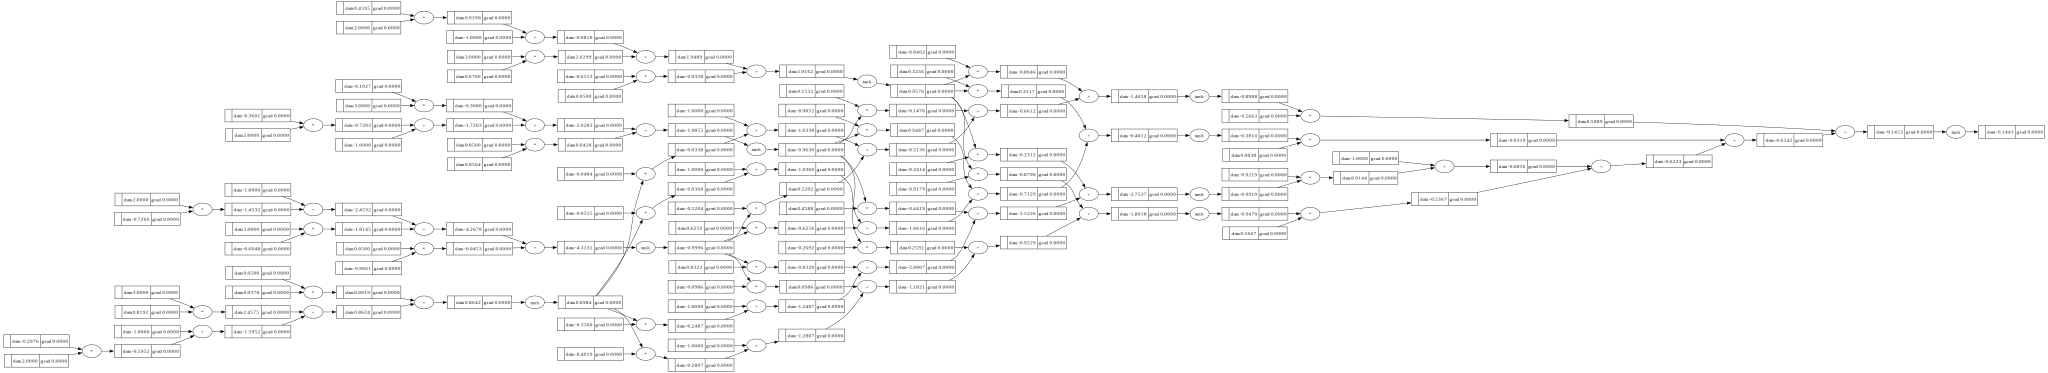

In [300]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

draw_dot(n(x))

In [426]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets




In [427]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
    loss

    #zero grad
    #每轮 backward 前必须清零参数的 grad，因为 backward 使用 += 累加梯度贡献。如果不清零，历史梯度会混进当前轮，导致更新过大，训练不稳定甚至数值爆炸。
    for p in n.parameters():
        p.grad = 0.0 

    #backward
    loss.backward()

    #update

    for p in n.parameters():
        p.data += -0.5 * p.grad

    print(k, loss.data)


    

0 3.648100362059651
1 7.551492767546702
2 3.748165448506152
3 3.9291076518747396
4 1.2011842531119793e-05
5 1.200437828295988e-05
6 1.1996927911201367e-05
7 1.1989491374257101e-05
8 1.1982068630707959e-05
9 1.1974659639298497e-05
10 1.196726435894444e-05
11 1.1959882748719306e-05
12 1.1952514767868666e-05
13 1.1945160375792194e-05
14 1.1937819532060928e-05
15 1.1930492196399905e-05
16 1.1923178328699495e-05
17 1.1915877889009204e-05
18 1.1908590837535076e-05
19 1.1901317134645888e-05


In [428]:
ypred

[Value(data=0.9991910878437413),
 Value(data=-0.9995623756542648),
 Value(data=-0.9970351592214649),
 Value(data=0.9984949477258055)]

In [348]:
loss.backward()

In [349]:
n.layers[0].neurons[0].w[0].grad

-0.28453162697348355

In [387]:
n.layers[0].neurons[0].w[0].data

-0.6409662859429517

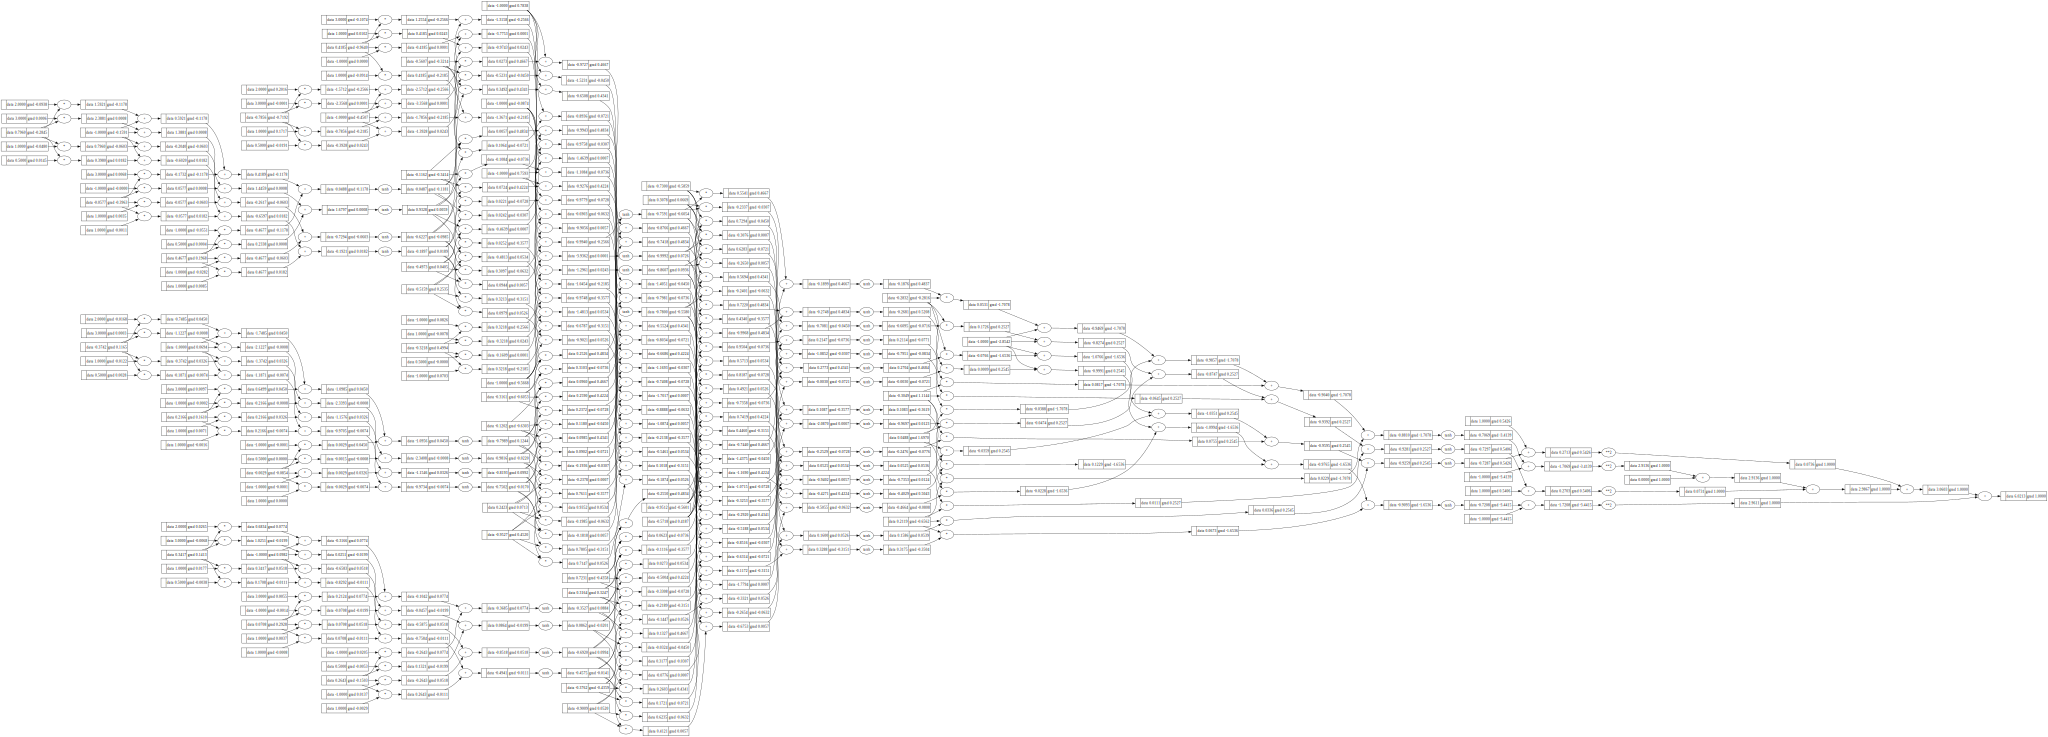

In [350]:
draw_dot(loss)

In [388]:
for p in n.parameters():
    p.data += -0.01 * p.grad